In [1]:
import osmnx as ox
import city2graph
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.lines import Line2D
from shapely.geometry import box

D:\GIS\Projects\venvs\copenhagen-walkability\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
city_name = "Copenhagen Municipality"
crs = 25832

admin = ox.geocode_to_gdf(city_name).to_crs(crs)
poi_gdf = ox.features_from_place(city_name, {"amenity": "cafe"}).to_crs(crs)

In [3]:
def plot_net_graph(boundaries_gdf=None, network_gdf=None, nodes_gdf=None, linewidth=0.4, alpha=0.7, color="#2b2b2b", markersize=6):
    fig, ax = plt.subplots(figsize=(10, 10))

    if boundaries_gdf is not None:
        boundaries_gdf.boundary.plot(ax=ax, linewidth=0.5, color="#2b2b2b")
    if network_gdf is not None:
        network_gdf.plot(ax=ax, linewidth=linewidth, color=color, alpha=alpha)
    if nodes_gdf is not None:
        nodes_color = "#" + color[6] + color[5] + color[4] + color[3] + color[2] + color[1]
        nodes_gdf.plot(ax=ax, linewidth=linewidth, color=nodes_color, alpha=alpha, markersize=markersize)

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

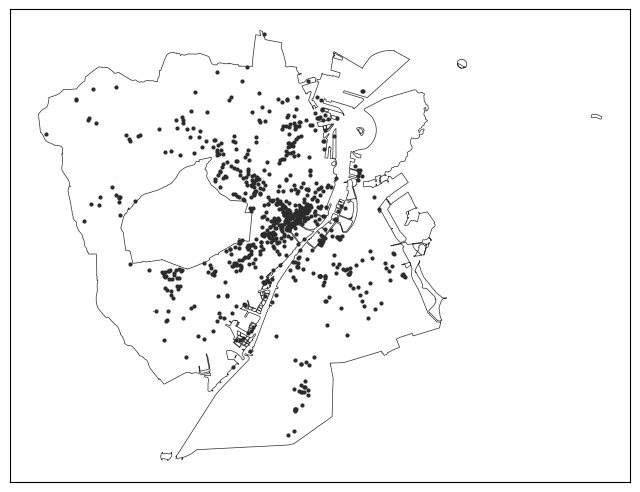

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))

admin.boundary.plot(ax=ax, linewidth=0.5, color="#2b2b2b")
poi_gdf.plot(ax=ax, markersize=4, color="#2b2b2b")

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

In [5]:
network_drive = ox.graph_to_gdfs(ox.graph_from_place(city_name, network_type="drive"), nodes=False).to_crs(crs)
network_walk = ox.graph_to_gdfs(ox.graph_from_place(city_name, network_type="walk"), nodes=False).to_crs(crs)

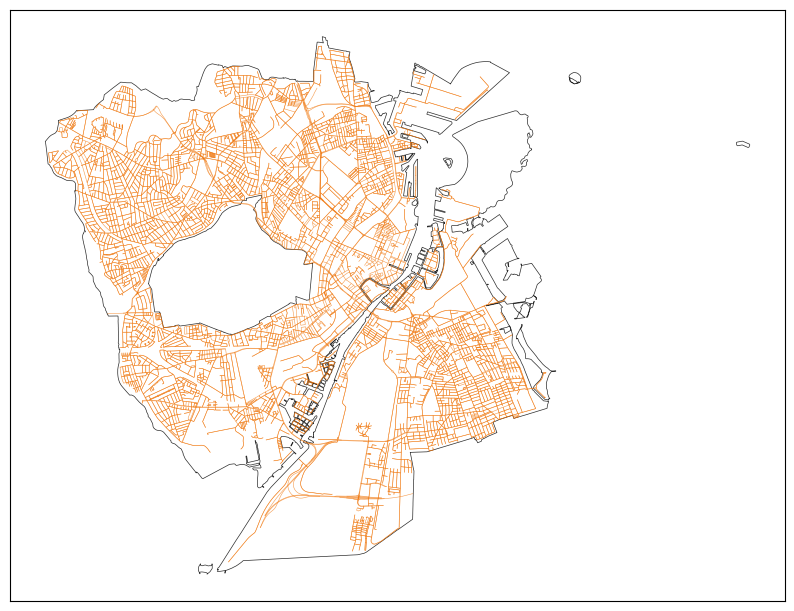

In [6]:
plot_net_graph(admin, network_drive, color="#f07102")

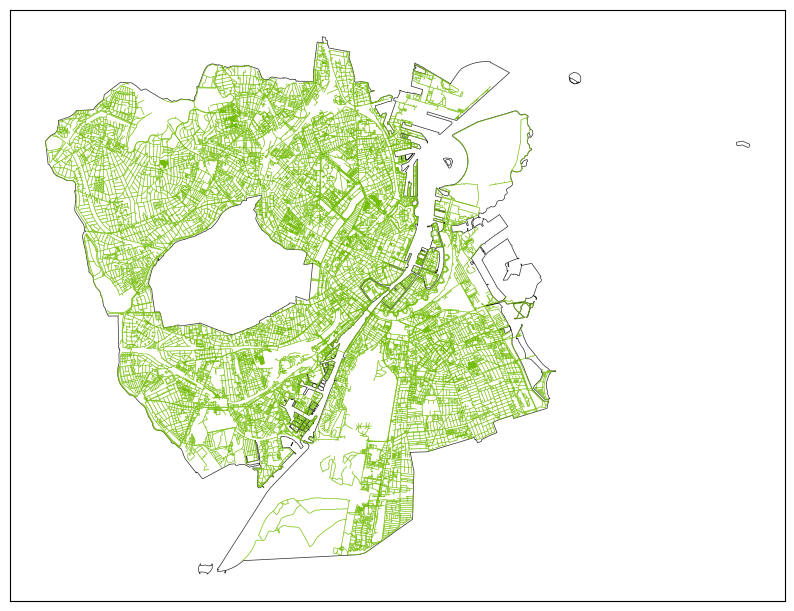

In [7]:
plot_net_graph(admin, network_walk, color="#72bd02")

Identifying routes between café locations that are separated by a specified maximum distance (walking time and distance)
- 5 minutes (~400 m)
- 10 minutes (~800 m)
- 15 minutes (~1200 m)

In [8]:
# 5 minutes (~400 m)

radius_5min = 400
wax_net_nodes_5min, wax_net_edges_5min = city2graph.waxman_graph(
    poi_gdf,
    distance_metric="network",
    r0=radius_5min,
    network_gdf=network_walk,
    beta=0.5
)

In [9]:
# 10 minutes (~800 m)

radius_10min = 800
wax_net_nodes_10min, wax_net_edges_10min = city2graph.waxman_graph(
    poi_gdf,
    distance_metric="network",
    r0=radius_10min,
    network_gdf=network_walk,
    beta=0.5
)

In [10]:
# 15 minutes (~1200 m)

radius_15min = 1200
wax_net_nodes_15min, wax_net_edges_15min = city2graph.waxman_graph(
    poi_gdf,
    distance_metric="network",
    r0=radius_15min,
    network_gdf=network_walk,
    beta=0.5
)

In [11]:
len(wax_net_edges_5min)

4109

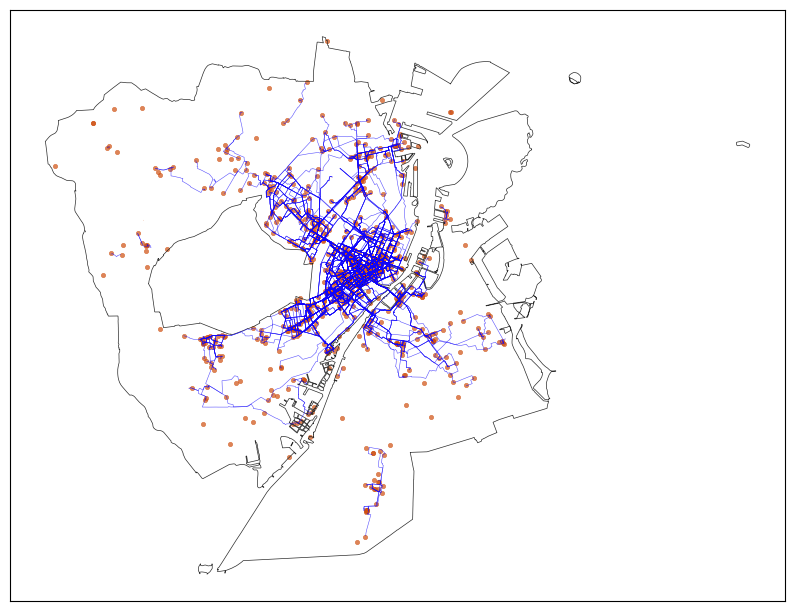

In [12]:
plot_net_graph(admin, wax_net_edges_5min, wax_net_nodes_5min, color="#1105fc", markersize=10)

In [13]:
len(wax_net_edges_10min)

11162

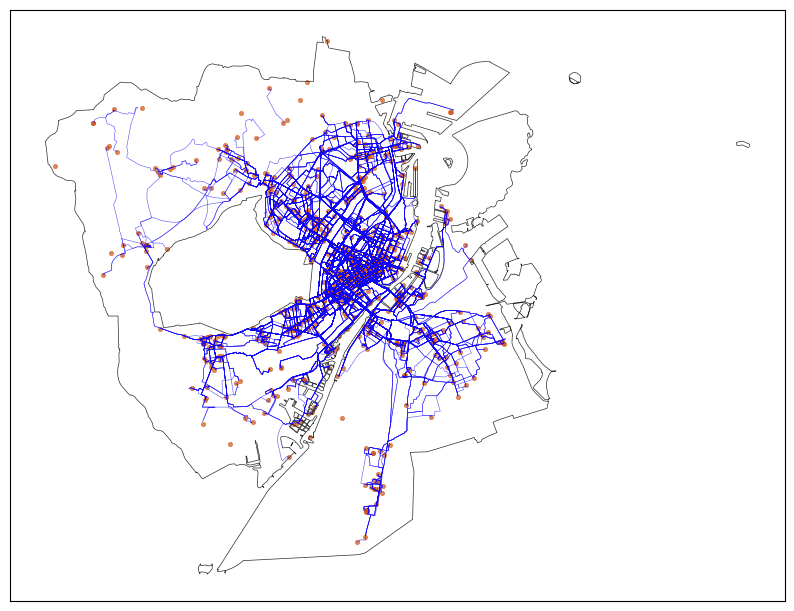

In [14]:
plot_net_graph(admin, wax_net_edges_10min, wax_net_nodes_10min, color="#1105fc", markersize=10)

In [15]:
len(wax_net_edges_15min)

18582

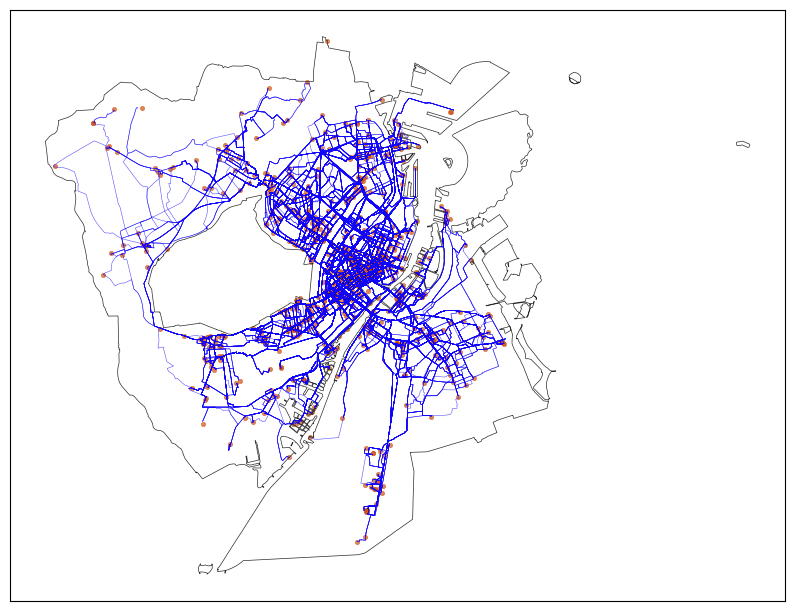

In [16]:
plot_net_graph(admin, wax_net_edges_15min, wax_net_nodes_15min, color="#1105fc", markersize=10)